In [ ]:
# Check and Handle Missing Data
#
# The process of dealing with MISSING values such that the NATURE(domain nature) of the data is preserved is called as IMPUTATION.
#
# Guidelines by PN to handle Missing data
# =============================================
#
# Missing data can be handled in 3 ways:
# 1. Pure Statistical Way
# 2. Domain Way
# 3. Hybrid Way
#
# ================================================
# Statistical Way
# ================================================
#
# a. Quantitative Data (Something that can be measured)(Numerical Data)
#            a. Continuous ND ---- Replace Missing value(np.nan / NaN) with the mean value of the column
#            b. Discrete ND ------ Replace Missing value(np.nan / NaN) with the median value of the column
#
# b. Qualitative Data (Non-numerical cols)
#            Replace Missing Value with the Mode's first value of the column
#
# ==================================================
# Domain Way
# ===================================================
# Replace Missing value with the default value of the column
# Default value can be derived from domain expert
#
# e.g. Real estate in Mumbai, Maharashtra, India
# MMRDA and RERA ----------- Guideliness and Policies For Car parking
#
# Builder is offering
# 2BHK ---------------------> 1 car parking
# 3BHK ---------------------> 2 car parking
# 4BHK or more -------------> 3 car parking
#
#
# Column ---> Parking (Missing value)
#
#  dataset
#
#  nBedrooms,parking,costPerSqFt
#  2,NaN,8888
#  3, 2, 10000
#  3, nan, 9899
#  2, nan, 8888
#
#
#  2,1,8888
#  3, 2, 10000
#  3, 2, 9899
#  2, 1, 8888
#
# =====================================================
# Hybrid way
# =====================================================
# Some columns will follow stat approach while others follow domain approach

In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv('preprocessExample.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    9 non-null      object 
 1   Age        9 non-null      float64
 2   Salary     9 non-null      float64
 3   Purchased  10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 452.0+ bytes


In [4]:
data.isna().sum()

Country      1
Age          1
Salary       1
Purchased    0
dtype: int64

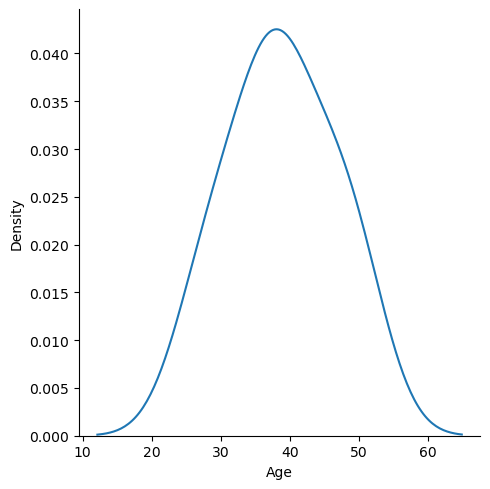

In [5]:
import seaborn as sns
sns.displot(data['Age'], kind='kde')

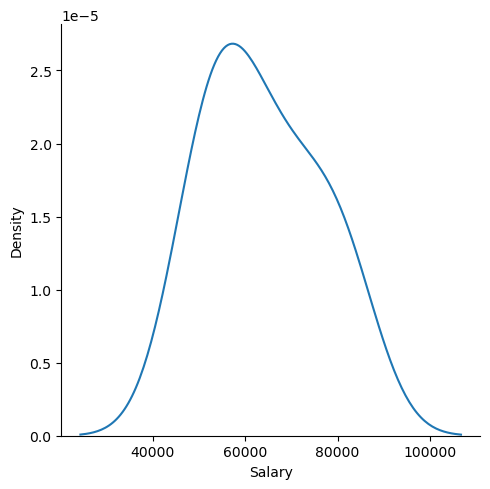

In [6]:
sns.displot(data['Salary'], kind='kde')

In [7]:
# ================================================
# Statistical Way
# ================================================
#
# a. Quantitative Data (Something that can be measured)(Numerical Data)
#            a. Continuous ND ---- Replace Missing value(np.nan / NaN) with the mean value of the column
#            b. Discrete ND ------ Replace Missing value(np.nan / NaN) with the median value of the column
#
# b. Qualitative Data (Non-numerical cols)
#            Replace Missing Value with the Mode's first value of the column

# #   Column     Non-Null Count  Dtype
#---  ------     --------------  -----
# 0   Country    9 non-null      object  ----------- Categorical Data
# 1   Age        9 non-null      float64 ----------- Discrete Data (1-100)
# 2   Salary     9 non-null      float64 ----------- Continuous Data
# 3   Purchased  10 non-null     object  ----------- Binary Data (Categorical data)


In [8]:
#Deal Country Column ----- categorical ( Replace Missing Value with the Mode's first value of the column)

data['Country'].mode()[0]

'France'

In [9]:
#fillna is a function responsible to replace np.nan with the provided value
data['Country'].fillna(data['Country'].mode()[0] , inplace=True)

#or
# data['Country'] = data['Country'].fillna(data['Country'].mode()[0])

C:\Users\shrid\AppData\Local\Temp\ipykernel_29780\1679190107.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Country'].fillna(data['Country'].mode()[0] , inplace=True)


In [10]:
data

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,France,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [11]:
# 1   Age        9 non-null      float64 ----------- Discrete Data (1-100)
#Replace Missing value(np.nan / NaN) with the median value of the column

data['Age'].median()

38.0

In [12]:
data['Age'].fillna( data['Age'].median() , inplace=True)

C:\Users\shrid\AppData\Local\Temp\ipykernel_29780\1721122748.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna( data['Age'].median() , inplace=True)


In [14]:
# 2   Salary     9 non-null      float64 ----------- Continuous Data
#a. Continuous ND ---- Replace Missing value(np.nan / NaN) with the mean value of the column
round(data['Salary'].mean() ,2)

np.float64(63777.78)

In [15]:
data['Salary'].fillna( round(data['Salary'].mean() ,2) , inplace=True)

C:\Users\shrid\AppData\Local\Temp\ipykernel_29780\2479977334.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Salary'].fillna( round(data['Salary'].mean() ,2) , inplace=True)


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    10 non-null     object 
 1   Age        10 non-null     float64
 2   Salary     10 non-null     float64
 3   Purchased  10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 452.0+ bytes


In [17]:
data

,Country,Age,Salary,Purchased
0,France,44.0,72000.00,No
1,Spain,27.0,48000.00,Yes
2,Germany,30.0,54000.00,No
3,Spain,38.0,61000.00,No
4,Germany,40.0,63777.78,Yes
5,France,35.0,58000.00,Yes
6,Spain,38.0,52000.00,No
7,France,48.0,79000.00,Yes
8,France,50.0,83000.00,No
9,France,37.0,67000.00,Yes


In [18]:
 #Categorical Data Handling
#
# Ideally there are 3 ways to encode a categorical column such that the data becomes
# compatible for analysis or Inferential Stats
#
# 1. One Hot Encoding (Dummy Variables)
# 2. Frequency Encoding
# 3. Mean Encoding
# 4. Target Encoding

In [19]:
# 2. Frequency Encoding
#
# This encoding technique replaces each category with how often it appears (count | proportion)
# This technique is useful:
#   a. The categories dont have a natural order but their frequencies carries information.
#.  b. Good for tree-based models (RandomForest, XGBoots, LightGBM)
#.  c. Works well when you have very high-cardinality categorical features and you want a compact representation
#
#e.g. Encoding city names in a dataset for Online Purchases (Retail Domain) --- Big cities may appear more often and the model
#.    or analysis may take leverage of that.

In [20]:
# 3. Mean Encoding
#
# This encoding replaces each category with the mean of the target for that category (This technique is only useful for modelling
# i.e. for inferential stats)
#
# When to use Mean Encoding?
#    1. When the categorical variable has a strong relationship with the target
#
# e.g. In predicting loan defaults, encoding employer name by default rate is more predictive

In [21]:
# 4. Target Encoding
# Replace categories with a function (mean,likelihood,smoothing etc) of a target (Used in inferential Stats)
# Function means:
#     a. Mean (Mean TArget Encoding) ---- most commonly used
#     b. Likelihood Encoding ------------ probability of target given category
#     c. Smoothing Encoding ------------- balance between Global Mean and Category Mean.
#
# e.g. Comparing Mumbai v/s Udupi on the fame of my product

In [22]:
#Dummy Variable Creation
# get_dummies

pd.concat([pd.get_dummies(data['Country'], dtype=int), data['Country']], axis = 1)

,France,Germany,Spain,Country
0,1,0,0,France
1,0,0,1,Spain
2,0,1,0,Germany
3,0,0,1,Spain
4,0,1,0,Germany
5,1,0,0,France
6,0,0,1,Spain
7,1,0,0,France
8,1,0,0,France
9,1,0,0,France


In [23]:
finalDataset = pd.concat( [pd.get_dummies(data['Country'] , dtype=int) , data.iloc[:,[1,2,3]]] ,axis = 1 )

In [24]:
#Frequency Encoding
#When not to use -----> When proportion is same for multiple categories

freq = data['Country'].value_counts(normalize=True) #-------- This returns the proportion (normalize=True)
freq

Country
France     0.5
Spain      0.3
Germany    0.2
Name: proportion, dtype: float64

In [25]:
data['CountryEncoded'] = data['Country'].map(freq)

data

,Country,Age,Salary,Purchased,CountryEncoded
0,France,44.0,72000.00,No,0.5
1,Spain,27.0,48000.00,Yes,0.3
2,Germany,30.0,54000.00,No,0.2
3,Spain,38.0,61000.00,No,0.3
4,Germany,40.0,63777.78,Yes,0.2
5,France,35.0,58000.00,Yes,0.5
6,Spain,38.0,52000.00,No,0.3
7,France,48.0,79000.00,Yes,0.5
8,France,50.0,83000.00,No,0.5
9,France,37.0,67000.00,Yes,0.5


In [26]:
#Target Encoding
data

,Country,Age,Salary,Purchased,CountryEncoded
0,France,44.0,72000.00,No,0.5
1,Spain,27.0,48000.00,Yes,0.3
2,Germany,30.0,54000.00,No,0.2
3,Spain,38.0,61000.00,No,0.3
4,Germany,40.0,63777.78,Yes,0.2
5,France,35.0,58000.00,Yes,0.5
6,Spain,38.0,52000.00,No,0.3
7,France,48.0,79000.00,Yes,0.5
8,France,50.0,83000.00,No,0.5
9,France,37.0,67000.00,Yes,0.5


In [27]:
#Group by country and get mean of salary for each country

groupedData = data.groupby('Country')['Salary'].mean()
groupedData

Country
France     71800.000000
Germany    58888.890000
Spain      53666.666667
Name: Salary, dtype: float64

In [28]:
data['CountryEncoded2'] = data['Country'].map(groupedData)

data

,Country,Age,Salary,Purchased,CountryEncoded,CountryEncoded2
0,France,44.0,72000.00,No,0.5,71800.000000
1,Spain,27.0,48000.00,Yes,0.3,53666.666667
2,Germany,30.0,54000.00,No,0.2,58888.890000
3,Spain,38.0,61000.00,No,0.3,53666.666667
4,Germany,40.0,63777.78,Yes,0.2,58888.890000
5,France,35.0,58000.00,Yes,0.5,71800.000000
6,Spain,38.0,52000.00,No,0.3,53666.666667
7,France,48.0,79000.00,Yes,0.5,71800.000000
8,France,50.0,83000.00,No,0.5,71800.000000
9,France,37.0,67000.00,Yes,0.5,71800.000000
